#  Evolutionary Multiple-objective Optimization (part for 5.0)

Introduce at least two different, and interesting, modifications to your evolutionary algorithm. These can alter the same part of the method (e.g., two novel reproduction operators) or different parts. Note that these should not be minor modifications but substantial ones whose contribution can be justified. Overall, three (2 + your current implementation) variants should be run and evaluated (illustration of final populations, convergence plots).

 - Mateusz Tabaszewski 151945
 - Bartłomiej Pukacki 151942

# Introduction

This notebook presents a comparison between the base MOAE/D implementation and its two meaningful extensions. Each variant builds on the original algorithm in different ways to potentially enhance performance in multi-objective optimization tasks:

 - Base – This refers to the original MOAE/D model, where the mutation operator is static and does not adapt to the context or history of previous improvements. It serves as a benchmark for evaluating the impact of more adaptive strategies.

 - Guided – This version of the MOAE/D algorithm introduces an adaptive mutation strategy informed by recent improvements. Specifically, it considers the change in weights that led to successful improvements over the last two iterations for a given scalarizing function. The mutation operator is then guided by this historical information, modifying weights in a direction that previously resulted in better outcomes.

 - Varied – This variant employs a two-stage mutation process designed to balance exploration and exploitation. Initially, a mutation operator promotes diversity by making large, disruptive changes to generate a wide spread of solutions. This is followed by a second operator that encourages convergence: it evaluates the best current solution according to the scalarizing function, then mutates the offspring’s weights by drawing inspiration from this best individual’s weight configuration.

## Imports and Declarations

In [1]:
from utils.MOO_utilities import *

In [2]:
### SOLVE HERE

ORDER = ["SuperFuture", "Apples", "WorldNow", "Electronics123", "Photons", "SpaceNow", "PearPear",
         "PositiveCorrelation", "BetterTechnology", "ABCDE", "EnviroLike", "Moneymakers", "Fuel4",
         "MarsProject", "CPU-XYZ", "RoboticsX", "Lasers", "WaterForce", "SafeAndCare", "BetterTomorrow"]

## Data

The data shows 20 ficticious stocks over time, the regression values are taken from the first notebook and were calculated using Linear Regression.

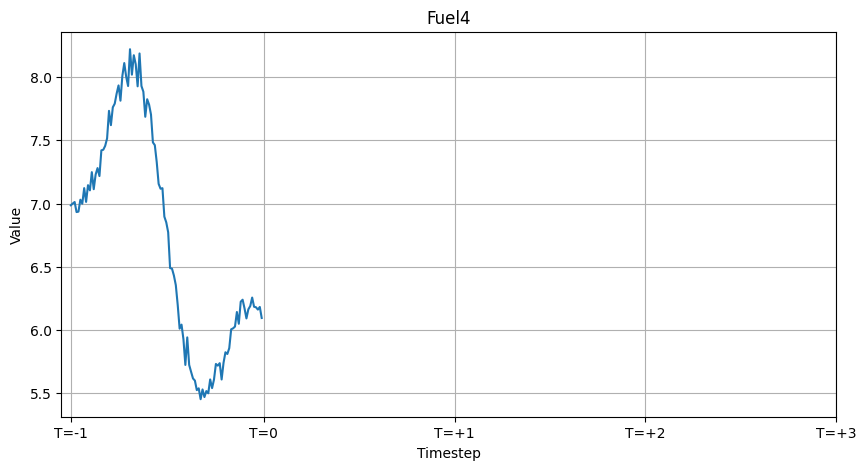

In [3]:
dr = DataReader("./data/Bundle1")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

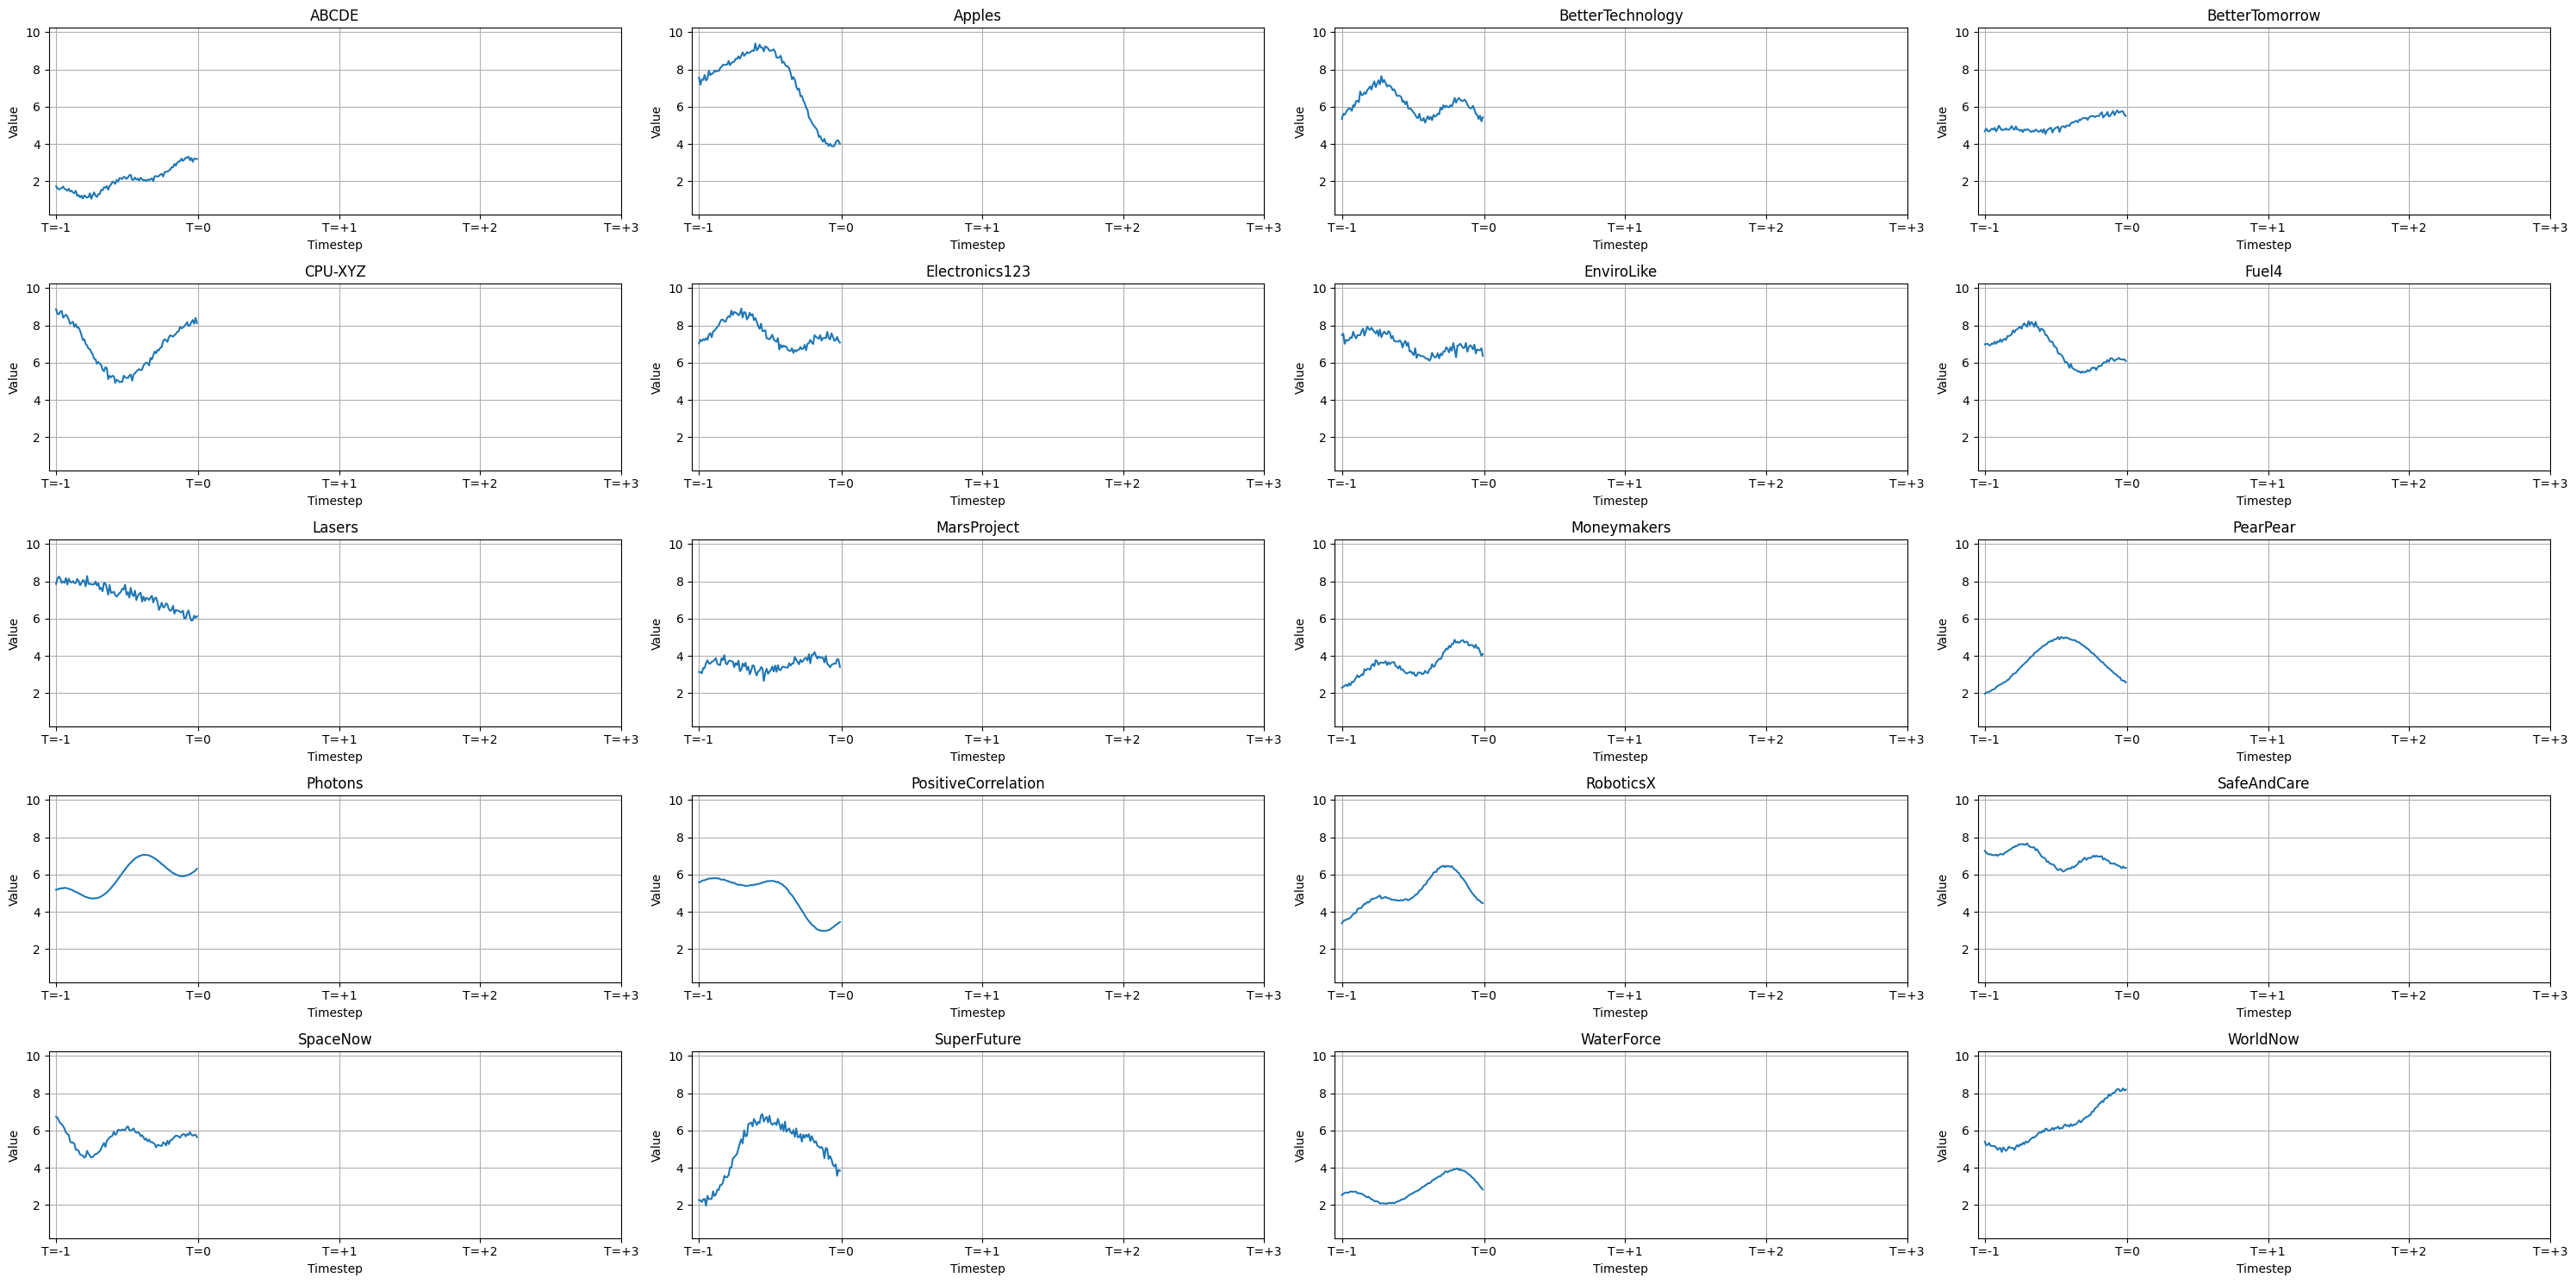

In [4]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

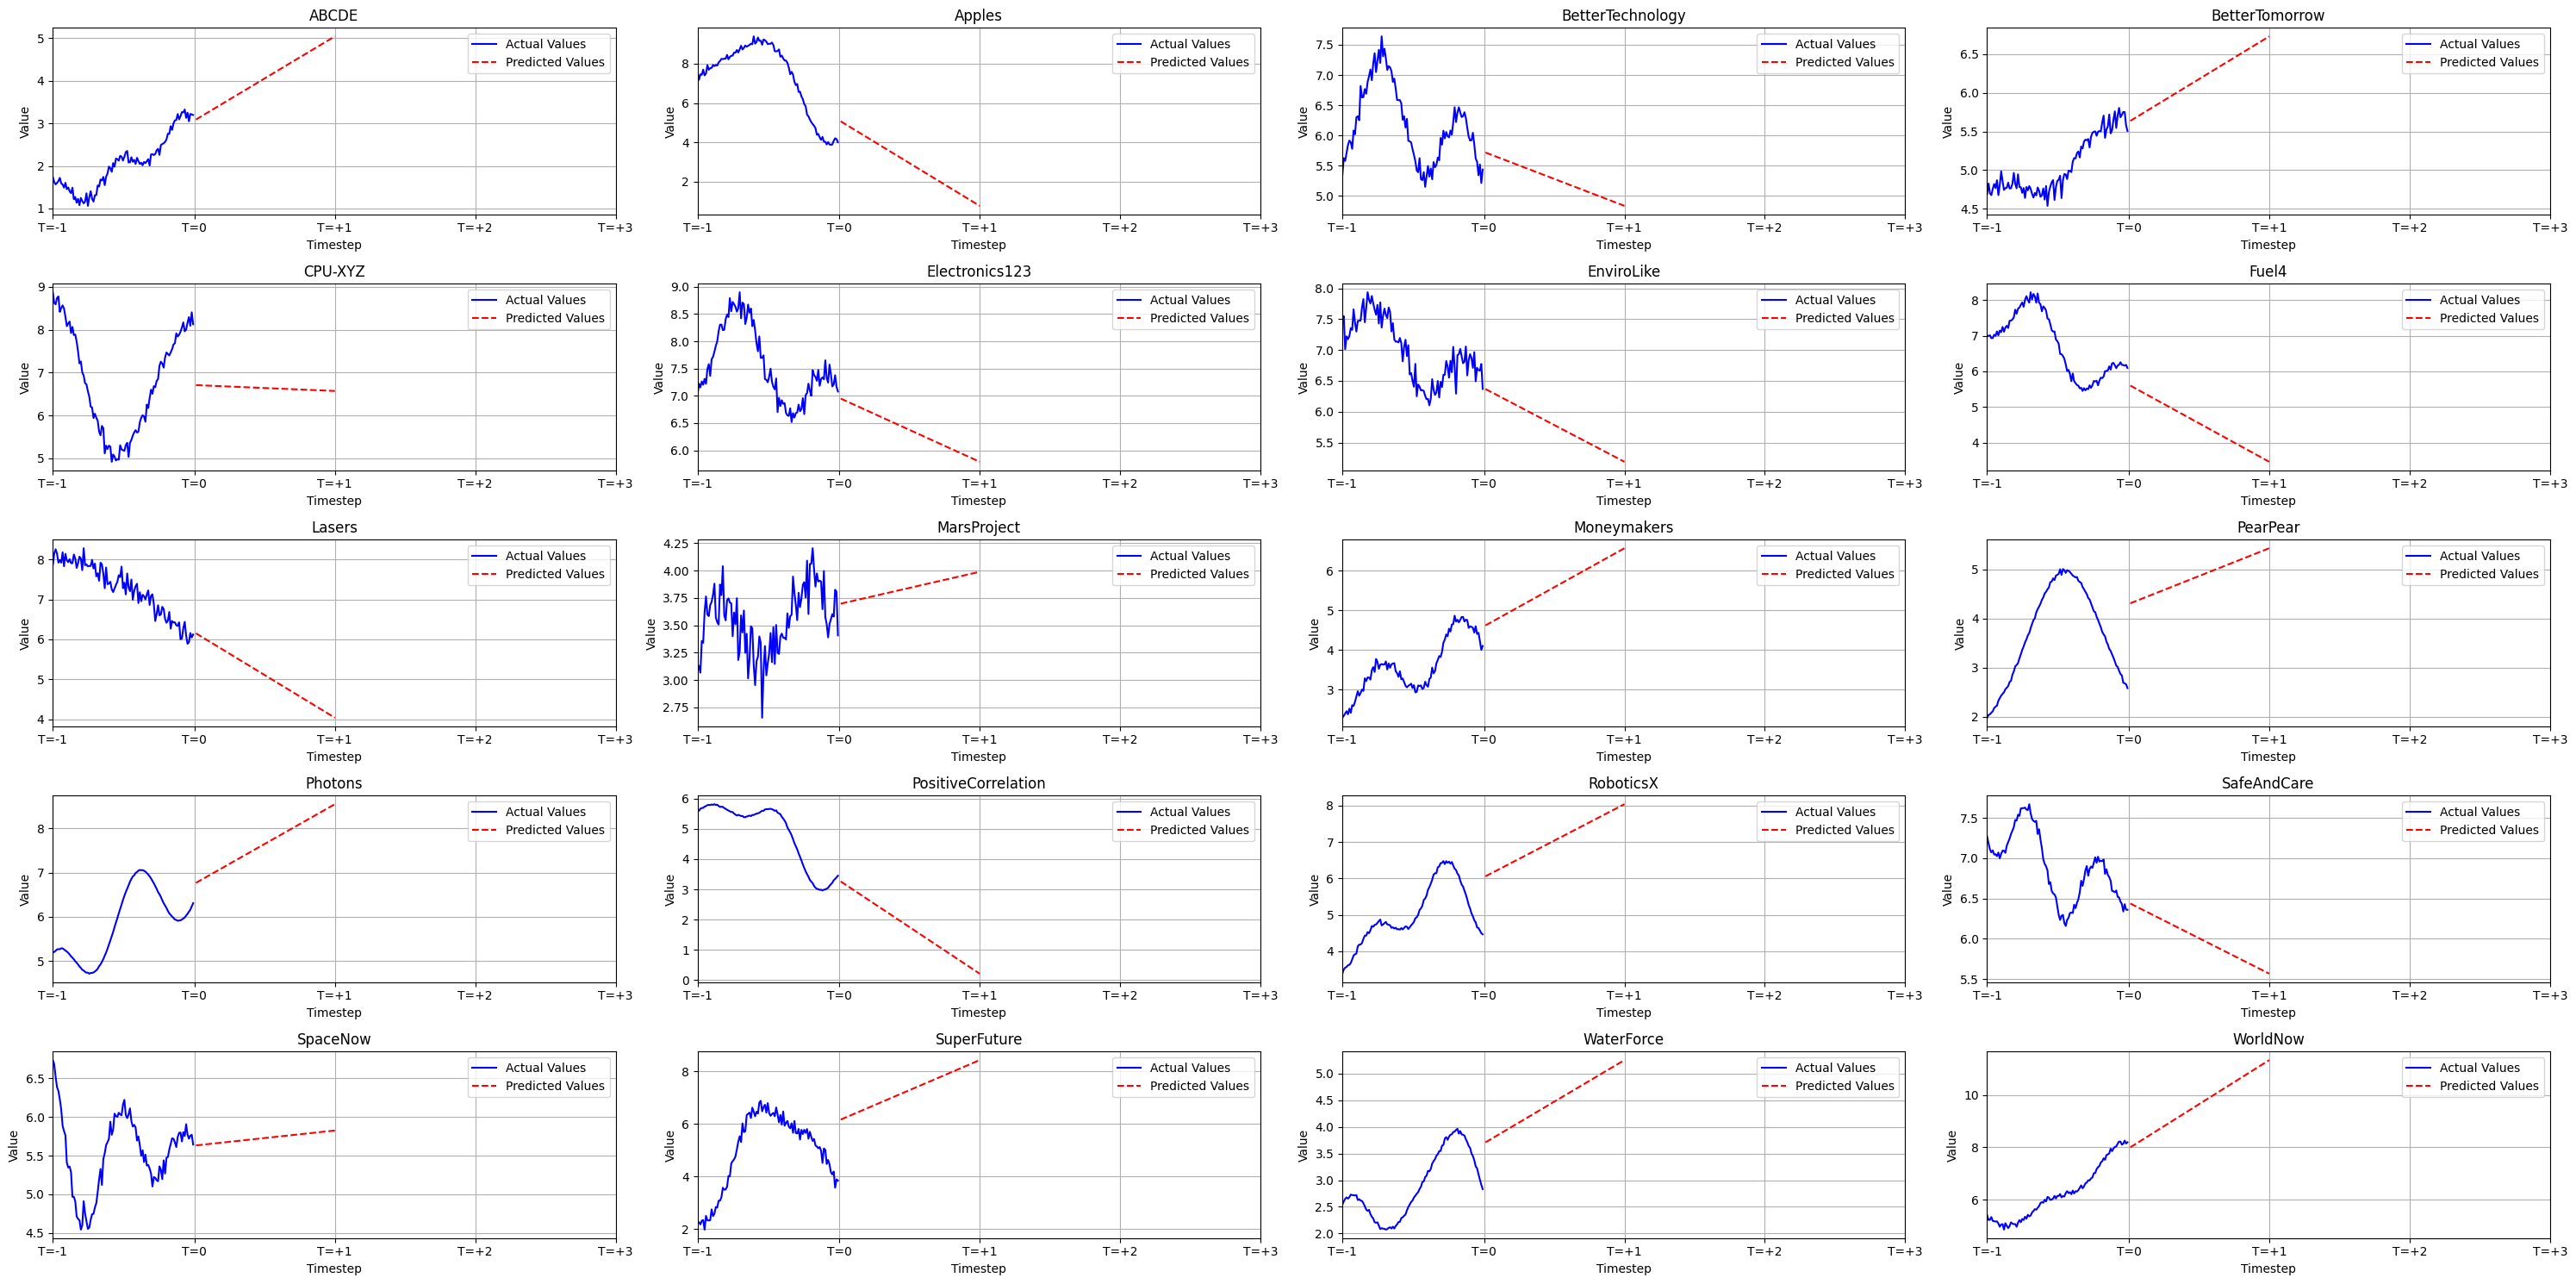

In [5]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_linear()
linear_predictions = RMC.predict_linear()
RMC.plot_predictions(val_range=201, predictions=linear_predictions, figsize=(30, 15))

In [6]:
risks = RMC.get_covariance_matrix()

## MOAE/D

## 2D - Case

In [7]:
GS_basic = GeneticSolver(data, linear_predictions, risks, population_size=30, mutation_probability=0.8, weight_size=20, num_dimensions=2)
population_basic = GS_basic.genetic_optimize(generations=100, neighborhood_size=5)
solutions_basic = GS_basic.get_solutions_from_population(population_basic)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


In [8]:
GS_guided = GeneticSolverGuided(data, linear_predictions, risks, population_size=30, mutation_probability=0.8, weight_size=20, num_dimensions=2)
population_guided = GS_guided.genetic_optimize(generations=100, neighborhood_size=5)
solutions_guided = GS_guided.get_solutions_from_population(population_guided)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


In [9]:
GS_varied = GeneticSolverVaried(data, linear_predictions, risks, population_size=30, mutation_probability=0.8, weight_size=20, num_dimensions=2)
population_varied = GS_varied.genetic_optimize(generations=100, neighborhood_size=5)
solutions_varied = GS_varied.get_solutions_from_population(population_varied)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


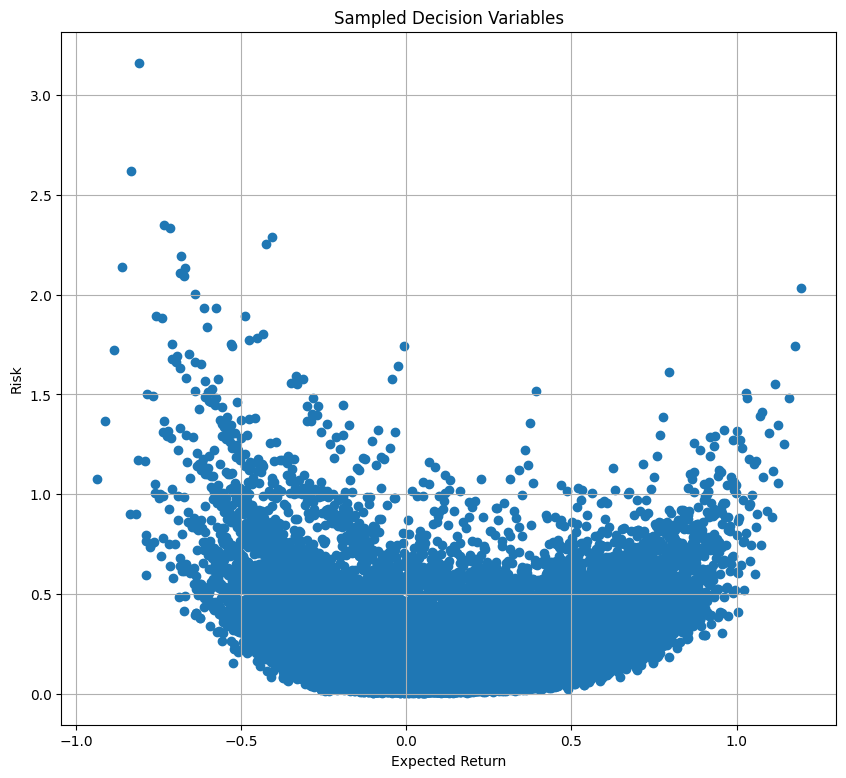

In [10]:
GS_basic.plot_sampled_decision_variables(20, 0.2)

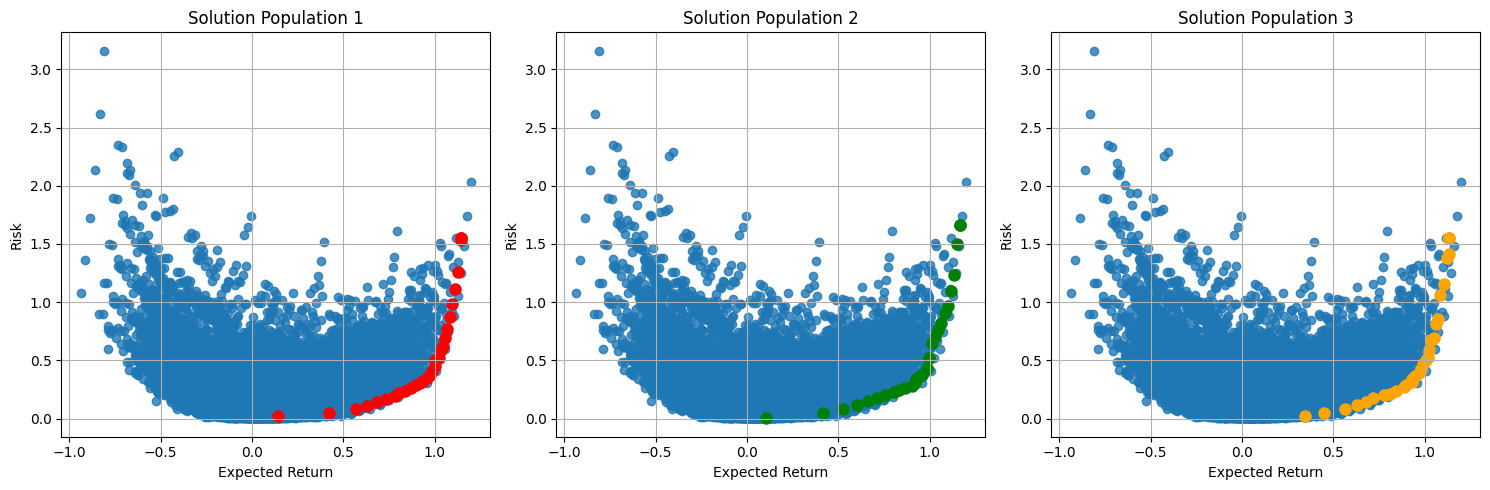

In [11]:
GS_basic.plot_many(solutions_basic, solutions_guided, solutions_varied)

### 3D-Case

In case of the 3D-case an additional objective to be minimized was defined as number of very small weights ( <0.01 ) in the final decision vector.

In [12]:
GS_basic = GeneticSolver(data, linear_predictions, risks, population_size=150, mutation_probability=0.8, weight_size=20, num_dimensions=3)
population_basic = GS_basic.genetic_optimize(generations=150, neighborhood_size=5)
solutions_basic = GS_basic.get_solutions_from_population_3D(population_basic)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


In [13]:
GS_guided = GeneticSolverGuided(data, linear_predictions, risks, population_size=150, mutation_probability=0.8, weight_size=20, num_dimensions=3)
population_guided = GS_guided.genetic_optimize(generations=150, neighborhood_size=5)
solutions_guided = GS_guided.get_solutions_from_population_3D(population_guided)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


In [14]:
GS_basic = GeneticSolver(data, linear_predictions, risks, population_size=150, mutation_probability=0.8, weight_size=20, num_dimensions=3)
population_varied = GS_basic.genetic_optimize(generations=150, neighborhood_size=5)
solutions_varied = GS_basic.get_solutions_from_population_3D(population_varied)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


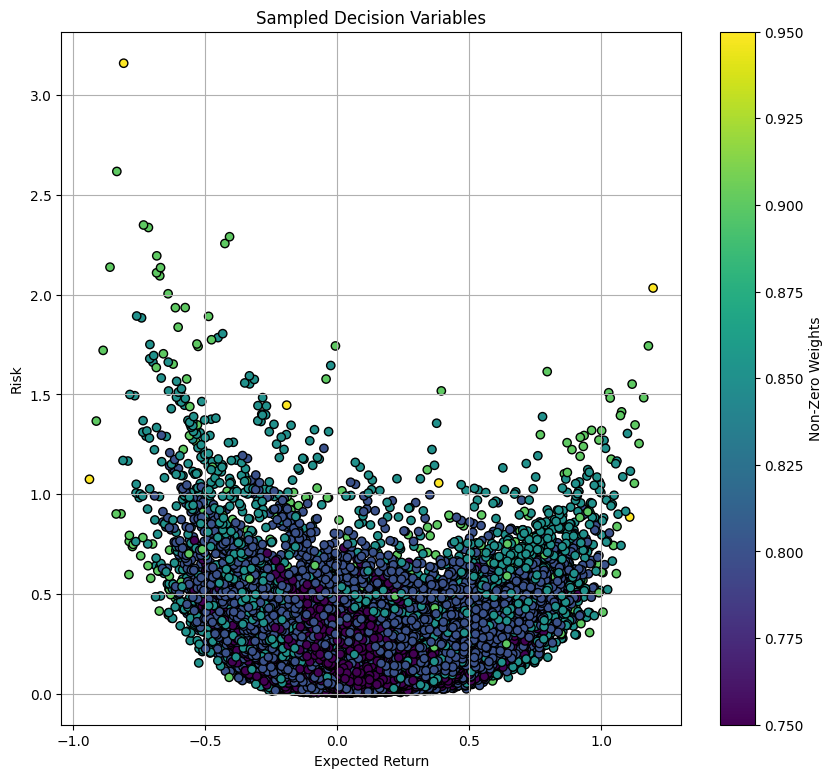

In [15]:
GS_basic.plot_sampled_3D()

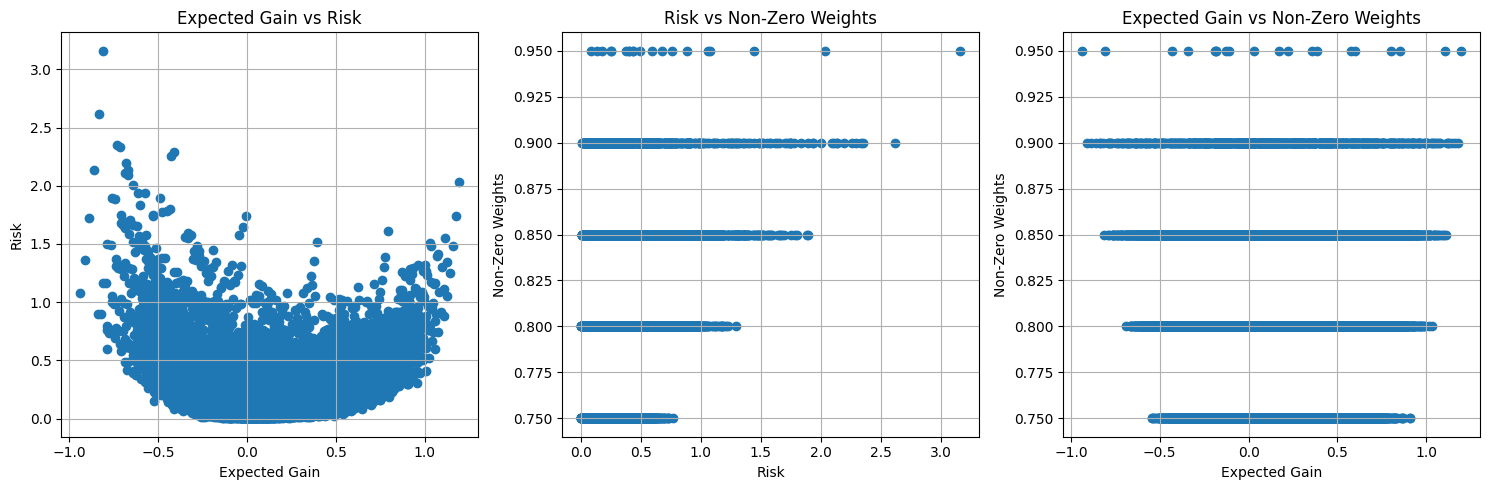

In [16]:
GS_basic.plot_sampled_3D(color=False)

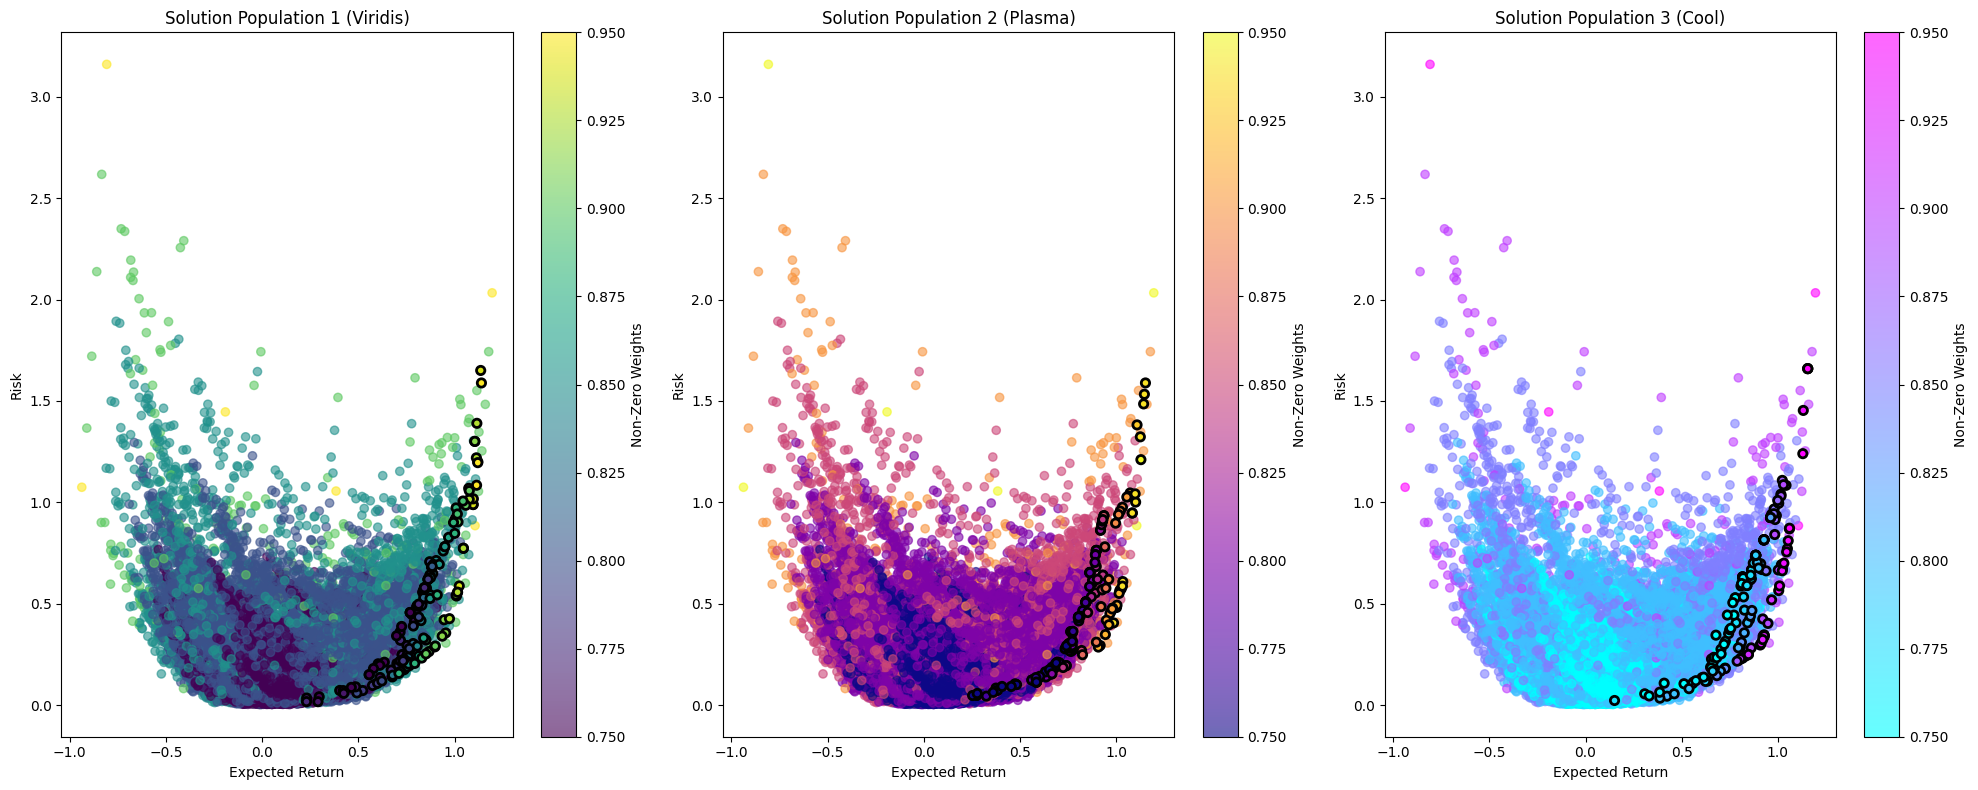

In [17]:
GS_basic.plot_many_3D(solutions_basic, solutions_guided, solutions_varied)

In [18]:
GS_basic.plot_front_real_3D(solutions_basic, color=True, colorscale="aggrnyl")

In [19]:
GS_basic.plot_front_real_3D(solutions_guided, color=True, colorscale="agsunset")

In [20]:
GS_basic.plot_front_real_3D(solutions_varied, color=True, colorscale="pubu")

In [21]:
GER = GeneticExperimentRunner()
GER.get_convergence(data, linear_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e

d:\MOO\MOO_env\lib\site-packages\pymoo\vendor\hv.py:98: RuntimeWarning:

overflow encountered in cast

d:\MOO\MOO_env\lib\site-packages\pymoo\vendor\hv.py:244: RuntimeWarning:

overflow encountered in cast

d:\MOO\MOO_env\lib\site-packages\pymoo\vendor\hv.py:258: RuntimeWarning:

overflow encountered in cast



     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e

d:\MOO\MOO\utils\MOO_utilities.py:1737: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

d:\MOO\MOO\utils\MOO_utilities.py:1737: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

d:\MOO\MOO\utils\MOO_utilities.py:1737: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



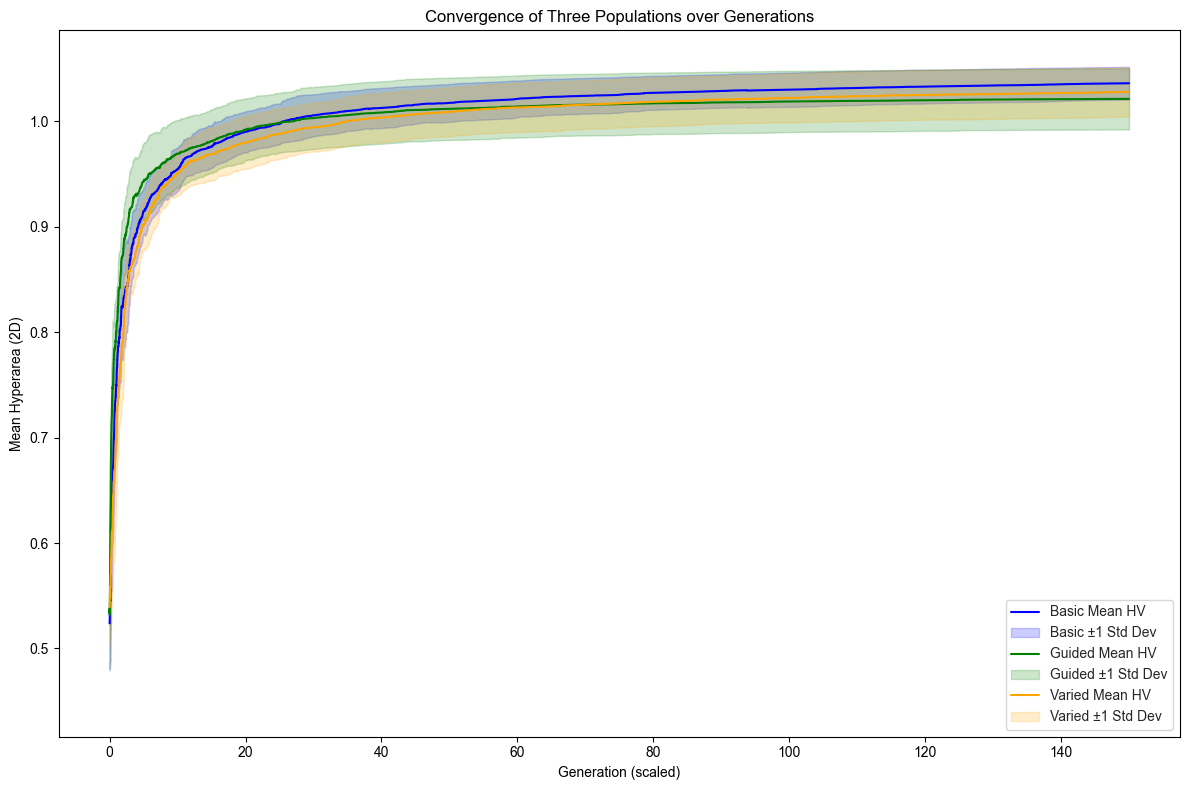

In [22]:
GER.plot_convergence()

In [23]:
GER.get_genetic_vs_classic(data, linear_predictions, risks, num_retries=10)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e

## MOAE/D VS Classical Methods

d:\MOO\MOO\utils\MOO_utilities.py:1633: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

d:\MOO\MOO\utils\MOO_utilities.py:1633: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

d:\MOO\MOO\utils\MOO_utilities.py:1633: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



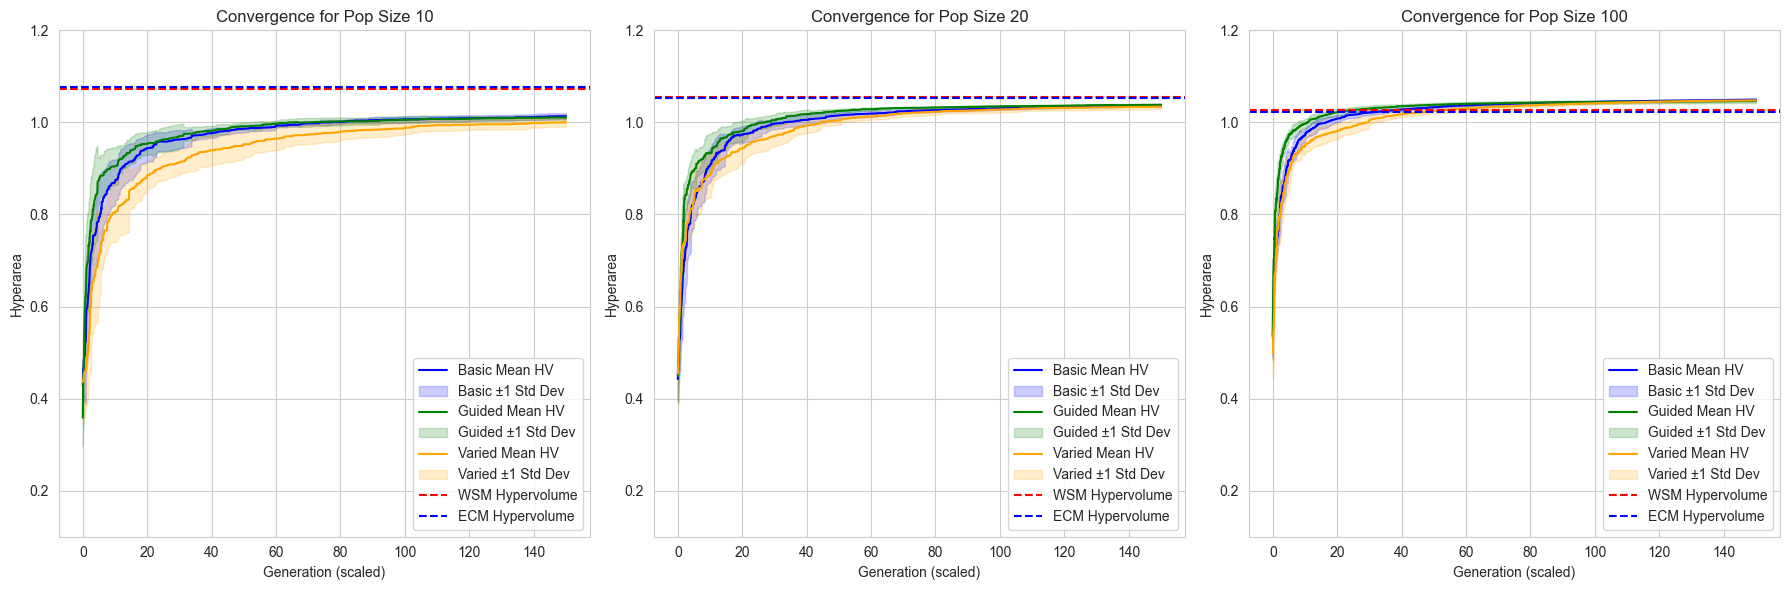

In [24]:
GER.plot_genetic_vs_classic()

## Conclusions

## The plots indicate several key observations:

 - All MOAE/D-based approaches outperform classical methods such as Weighted Sum Method (WSM) and Epsilon Constraint Method (ECM), provided that the number of generations and population size are sufficiently large.

 - The Guided approach consistently outperforms the Base variant in scenarios with a limited number of generations. However, as the number of generations increases, the performance gap narrows, and both approaches tend to produce nearly indistinguishable results.

 - This convergence in performance is likely due to the diminishing utility of the Guided variant’s historical adaptation. As the search progresses, the accumulated history may no longer provide useful direction for improvement, and stronger, more exploratory mutations might be needed.

 - The Varied approach performs the worst during early generations, primarily due to its aggressive spreading mutation strategy, which prioritizes diversity over immediate convergence. However, its performance improves significantly once the mutation strategy shifts toward convergence-focused refinement.

 - Given a high number of generations and a large population size, Varied becomes competitive with, and sometimes even superior to, both the Base and Guided variants.

## General Recommendations:

 - If you need good solutions in a short time frame with a small population size, the Guided approach is the most effective choice.

 - If you're working with a large population and can afford a high number of generations, the Varied approach becomes more advantageous due to its balance between exploration and convergence.

 - For moderate scenarios, where computational resources and time are limited but not minimal, the Base approach provides a reliable and balanced baseline.